In [1]:
import pandas as pd
import numpy as np
import urllib.request

url = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv"
df = pd.read_csv(url, sep=',')
df.head()


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [2]:
df = df.rename(columns={'MSRP': 'price'})

In [3]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [4]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,price
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
y = df["price"]

x = df.drop(columns = ["price"])

In [6]:
string_feat = list(df.dtypes[df.dtypes == 'object'].index)

In [7]:
for col in string_feat:
    df[col] = df[col].str.lower().str.replace(" ", "_")

In [8]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:10])
    print(df[col].nunique())

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler' 'nissan' 'volvo' 'mazda'
 'mitsubishi' 'ferrari']
48
model
['1_series_m' '1_series' '100' '124_spider' '190-class' '2_series' '200'
 '200sx' '240sx' '240']
914
year
[2011 2012 2013 1992 1993 1994 2017 1991 2016 1990]
28
engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel'
 'electric' 'flex-fuel_(premium_unleaded_recommended/e85)' 'natural_gas'
 'flex-fuel_(premium_unleaded_required/e85)'
 'flex-fuel_(unleaded/natural_gas)']
10
engine_hp
[335. 300. 230. 320. 172. 160. 130. 158. 240. 248.]
356
engine_cylinders
[ 6.  4.  5.  8. 12.  0. nan 10.  3. 16.]
9
transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5
driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4
number_of_doors
[ 2.  4.  3. nan]
3
market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [10]:
log_price = np.log1p(df.price)

In [11]:
max = df.price.max()
min = df.price.min()

<Axes: xlabel='price', ylabel='Count'>

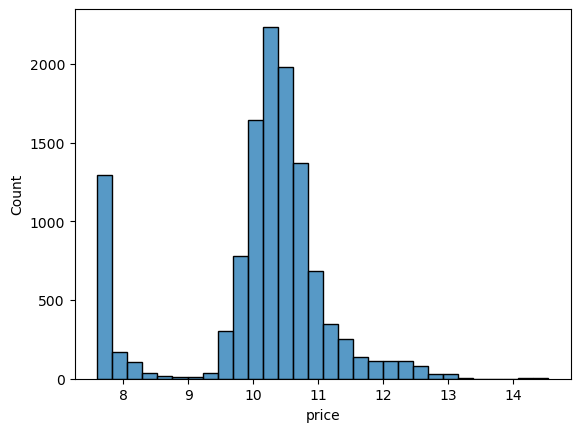

In [12]:
# plt.xlim(min, max)
sns.histplot(log_price, bins=30)


<Axes: xlabel='price', ylabel='Count'>

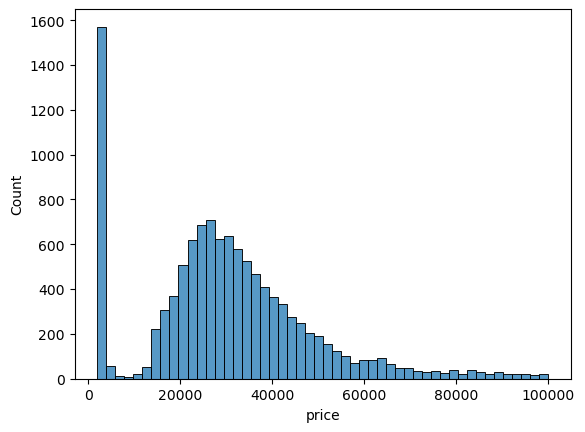

In [13]:
sns.histplot(df.price[df.price <= 100000], bins=50)

In [14]:
for col in df.columns:
    print(col)
    print(df[col].isnull().sum())

make
0
model
0
year
0
engine_fuel_type
3
engine_hp
69
engine_cylinders
30
transmission_type
0
driven_wheels
0
number_of_doors
6
market_category
3742
vehicle_size
0
vehicle_style
0
highway_mpg
0
city_mpg
0
popularity
0
price
0


In [15]:
n = len(df)

val_len = int(n * 0.2)
test_len = int(n * 0.2)
train_len = n - (val_len + test_len)

In [23]:
print(df.market_category.unique())
df.market_category = df.market_category.apply(lambda x: x.split(',') if pd.notna(x) else 0)

['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance' 'flex_fuel'
 'flex_fuel,performance' nan 'hatchback' 'hatchback,luxury,performance'
 'hatchback,luxury' 'luxury,high-performance,hybrid' 'diesel,luxury'
 'hatchback,performance' 'hatchback,factory_tuner,performance'
 'high-performance' 'factory_tuner,high-performance'
 'exotic,high-performance' 'exotic,factory_tuner,high-performance'
 'factory_tuner,performance' 'crossover' 'exotic,luxury'
 'exotic,luxury,high-performance' 'exotic,luxury,performance'
 'factory_tuner,luxury,performance' 'flex_fuel,luxury' 'crossover,luxury'
 'hatchback,factory_tuner,luxury,performance' 'crossover,hatchback'
 'hybrid' 'luxury,performance,hybrid'
 'crossover,luxury,performance,hybrid' 'crossover,luxury,performance'
 'exotic,factory_tuner,luxury,high-performance'
 'flex_fuel,luxury,high-performance' 'crossover,flex_fuel' 'diesel'
 'hatchback,diesel' 'crossover,luxury,diesel'
 'crossover,luxury,hi

In [44]:
market_category = set()
for i in df.market_category:
    if type(i) is not int:
        market_category.update(i)

In [45]:
category_dict = {idx+1:cat for idx, cat in enumerate(market_category)}
category_dict[0] = 'nan'



In [46]:
print(category_dict)

{1: 'flex_fuel', 2: 'hatchback', 3: 'performance', 4: 'hybrid', 5: 'luxury', 6: 'crossover', 7: 'diesel', 8: 'exotic', 9: 'factory_tuner', 10: 'high-performance', 0: 'nan'}
